In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_health_combined_test.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv
/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_feature_engineered.csv


**Dataset used : /kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/mental_heath_unbanlanced.csv")

head() used to check starting top columns

In [3]:
df.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


status is the label we will predict on , value_counts() used to count total values present in the column

In [4]:
df['status'].value_counts()

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

isnull() is used to check null values in entire column using sum()

In [5]:
df.isnull().sum()

Unique_ID    9600
text            0
status          0
dtype: int64

duplicate is used to check dups value in column, which is important for prediction

In [6]:
# Count total duplicate rows (excluding the first occurrence of each set)
print(df.duplicated().sum())
print("shape of dataset",df.shape)

0
shape of dataset (49612, 3)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique_ID  40012 non-null  float64
 1   text       49612 non-null  object 
 2   status     49612 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.1+ MB


We need to drop unique_id as it is not necessary for prediction and dropna is used to drop where the text is empty

In [8]:
# Drop the unnecessary column
df = df.drop(columns=['Unique_ID'])

# Remove rows where text is empty or null
df = df.dropna(subset=['text'])

# Remove extra spaces from text
df['text'] = df['text'].str.strip()

# Reset index after cleaning
df = df.reset_index(drop=True)

# Final check
print(df.info())
print("\nSample data:")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    49612 non-null  object
 1   status  49612 non-null  object
dtypes: object(2)
memory usage: 775.3+ KB
None

Sample data:
                                                text   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


we need to convert the labels to number so that machine can understand 

In [9]:
# Define label mapping manually (very important for consistency)
label_mapping = {
    "Normal": 0,
    "Depression": 1,
    "Suicidal": 2,
    "Anxiety": 3
}



(.map) will map the label according label_mapping

***status will be dropped as we will use label***


In [10]:
df['label']=df['status'].map(label_mapping)
print("number of unmapped label:",df['label'].isnull().sum())
df=df.drop(columns=['status'])

# Final distribution check
print("\nLabel distribution after encoding:")
print(df["label"].value_counts())

print("\nSample data:")
print(df.head())

number of unmapped label: 0

Label distribution after encoding:
label
0    18391
1    14506
2    11212
3     5503
Name: count, dtype: int64

Sample data:
                                                text  label
0                                         oh my gosh      3
1  trouble sleeping, confused mind, restless hear...      3
2  All wrong, back off dear, forward doubt. Stay ...      3
3  I've shifted my focus to something else but I'...      3
4  I'm restless and restless, it's been a month n...      3


**dataset is separated so that we can predict Y on the basis of X(text)**
> train_test_split will sperate the data on the basis of ratio provided
> for example (80:20)

In [11]:
from sklearn.model_selection import train_test_split
x=df['text']
y=df['label']


It forces train and test to maintain the same ratio.
So if original data is:

90% class 0 

10% class 1

Then:Train (80 samples):

72 class 0

8 class 1

Test (20 samples):

18 class 0

2 class 1

Perfect distribution.

In [12]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)
# Check sizes
print("Training samples:", len(x_train))
print("Validation samples:", len(x_test))

# Check class distribution in train set
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

# Check class distribution in validation set
print("\nValidation distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 39689
Validation samples: 9923

Train distribution:
label
0    0.370707
1    0.292398
2    0.225982
3    0.110912
Name: proportion, dtype: float64

Validation distribution:
label
0    0.370654
1    0.292351
2    0.226041
3    0.110954
Name: proportion, dtype: float64


# TfidfVectorizer
is used to vectorized the text so that model can understand

**Pipeline isused for steady flow of model**

In [13]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

#create pipeline

base_model=Pipeline([
    ('tf',TfidfVectorizer(
        max_features=20000,#vocab size
        ngram_range=(1,2),
        stop_words=None #keep stopwords like is the and etc
        
    )),
    ('clf',LogisticRegression(
        max_iter=1000,
        class_weight='balanced' #handle imbalance in class
    ))
])
base_model.fit(x_train,y_train)
pred=base_model.predict(x_test)
print("Macro F1 Score:", f1_score(y_test, pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

Macro F1 Score: 0.7707024530728411

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3678
           1       0.75      0.63      0.68      2901
           2       0.68      0.73      0.70      2243
           3       0.74      0.85      0.79      1101

    accuracy                           0.79      9923
   macro avg       0.76      0.78      0.77      9923
weighted avg       0.78      0.79      0.78      9923



**Logistic Regression doesnt give us robust prediction hence we will use distilbert transformer from HuggingFace**

In [14]:
!pip install --upgrade transformers accelerate -q

import prerequisites : torch ,transformer,datasets for covertingto  HF dataset format and classification report for validating results

In [15]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from datasets import Dataset
from sklearn.metrics import classification_report

In [16]:
import torch
torch.cuda.is_available()

True

import transformer used tokenizer for better tokenization

In [17]:
from transformers import DistilBertTokenizerFast
tk=DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
print("tokeizer loaded successfully")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokeizer loaded successfully


In [18]:
from datasets import Dataset
#convert to dict format

train_dict={
    "text":list(x_train),
    "label":list(y_train)
}
test_dict={
    "text":list(x_test),
    "label":list(y_test)
}
#creating hugging face datset
train_dataset = Dataset.from_dict(train_dict)
test_dataset = Dataset.from_dict(test_dict)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 39689
})
Dataset({
    features: ['text', 'label'],
    num_rows: 9923
})


we have to provide text as an example ,padding(fixed amount of token to be provided as an input) , max_length is 128

In [19]:
def tokenize_function(example):
    return tk(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove original text column (model doesn't need raw text)
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# Set format for PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)

Map:   0%|          | 0/39689 [00:00<?, ? examples/s]

Map:   0%|          | 0/9923 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 39689
})


# Import classifier for our preditcion 


*It'll predict 4 classes ie 0,1,2,3  ie(normal,anxiety,depression,suicidal)*

In [20]:
from transformers import DistilBertForSequenceClassification

#load pretrained model
model=DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=4)#defined to predict 4 classes
print("model loaded successfully")
                                          

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded successfully


In [21]:
# Import numpy for numerical operations
import numpy as np  

# Import evaluation metrics from sklearn
from sklearn.metrics import classification_report, f1_score, recall_score  


# This function will be used during model evaluation (e.g., in HuggingFace Trainer)
def compute_metrics(eval_pred):
    
    # eval_pred contains two things:
    # 1. logits (raw model outputs before softmax)
    # 2. labels (true target values)
    logits, labels = eval_pred  

    # Convert raw logits into predicted class labels
    # axis=1 means: choose the class with highest score for each sample
    predictions = np.argmax(logits, axis=1)  

    # Calculate Macro F1 Score
    # "macro" means:
    #   - Compute F1 for each class separately
    #   - Then take average (treat all classes equally)
    macro_f1 = f1_score(labels, predictions, average="macro")  

    # Calculate Recall specifically for class label = 2
    # labels=[2] means we only want recall for class 2
    # average=None returns score per label (not averaged)
    suicidal_recall = recall_score(
        labels, 
        predictions, 
        labels=[2], 
        average=None
    )[0]  # [0] because it returns an array

    # Return metrics in dictionary format
    # Trainer expects dictionary output
    return {
        "macro_f1": macro_f1,
        "suicidal_recall": suicidal_recall
    }

augmentation ensures some tweaks for model so that it can learn pattern well and which text leads to which class

In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=100
)

In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [24]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Macro F1,Suicidal Recall
1,0.849937,0.857821,0.811876,0.748105
2,0.708551,0.805881,0.825381,0.752118
3,0.572169,0.818214,0.830339,0.765493


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3723, training_loss=0.79398930421799, metrics={'train_runtime': 959.5022, 'train_samples_per_second': 124.092, 'train_steps_per_second': 3.88, 'total_flos': 3943264578978816.0, 'train_loss': 0.79398930421799, 'epoch': 3.0})

In [25]:
trainer.save_model("mental_health_model_v1")
tk.save_pretrained("mental_health_model_v1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mental_health_model_v1/tokenizer_config.json',
 'mental_health_model_v1/tokenizer.json')

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model_path = "/kaggle/working/mental_health_model_v1"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [27]:
def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_class].item()

    return predicted_class, confidence, probs.tolist()[0]

In [28]:
# Define label mapping manually (very important for consistency)
label_map = {
    "Normal": 0,
    "Depression": 1,
    "Suicidal": 2,
    "Anxiety": 3
}


In [29]:
def safe_predict(text):
    if len(text.split()) < 5:
        return {
            "error": "Input too short. Please provide more detail."
        }

    pred_class, conf, probs = predict_text(text)

    return {
        "prediction": reverse_label_map[pred_class],
        "confidence": round(conf, 4),
        "probabilities": probs
    }
reverse_label_map = {v: k for k, v in label_map.items()}

# Prediction example :

In [30]:
res='Sometimes I wish I could just disappear and not wake up again.i dont want to live, i am going to end this'
safe_predict(res)

{'prediction': 'Suicidal',
 'confidence': 0.8802,
 'probabilities': [0.001040619914419949,
  0.11766964942216873,
  0.8802000284194946,
  0.0010896272724494338]}

**This confusion matrix shows how model predicting (correct prediction are diagonally)**

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


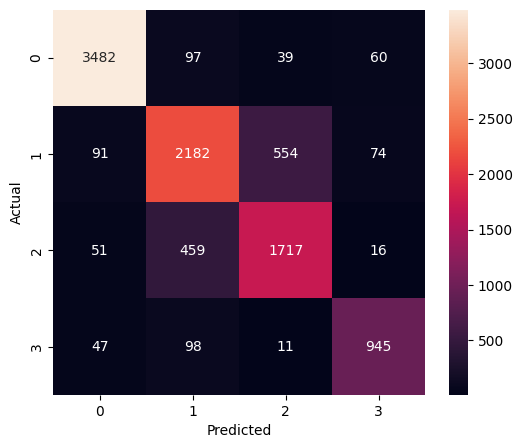

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
import shutil
shutil.rmtree("/kaggle/working/results")

In [34]:
!du -sh /kaggle/working/*

257M	/kaggle/working/mental_health_model_v1


# Zipped model so that we can use it for FastAPI

In [35]:
import shutil
shutil.make_archive('mental_health_model_final', 'zip', '/kaggle/working/mental_health_model_v1')

'/kaggle/working/mental_health_model_final.zip'